In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/brjapon/cwru-bearing-datasets/CWRU_48k_load_1_CNN_data.npz
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/feature_time_48k_2048_load_1.csv
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR021_1_214.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B014_1_190.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR007_6_1_136.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR014_6_1_202.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B007_1_123.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR007_1_110.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B021_1_227.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/Time_Normal_1_098.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR021_6_1_239.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR014_1_175.mat


# CWRU Bearing Fault Classification — 1D CNN

**Pipeline structure identical to Paderborn CNN notebook for transfer learning compatibility.**

Pipeline: Load → Preprocess → Split (before segmentation) → Segment → Augment → Train → Evaluate

In [2]:
import numpy as np
import os
import glob
from scipy.io import loadmat
from scipy.signal import butter, filtfilt

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

2026-03-20 23:46:22.502153: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774050382.663087      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774050382.710660      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774050383.104522      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774050383.104563      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774050383.104566      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 1. Hyperparameters

In [3]:
# ─── Hyperparameters (identical structure to Paderborn notebook) ───
FS            = 48000       # Sampling frequency (Hz) — CWRU drive-end @ 48 kHz
WINDOW_SIZE   = 1024        # Samples per segment
OVERLAP       = WINDOW_SIZE // 2   # 50% overlap
N_CLASSES     = 10          # Number of fault classes
BATCH_SIZE    = 64
EPOCHS        = 50
LEARNING_RATE = 1e-3

# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Data Configuration

In [4]:
DATA_DIR = "/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/"

# File mapping: filename prefix → (label_id, class_name)
# 10 classes: 1 normal + 3 ball faults + 3 inner race + 3 outer race
FILE_MAP = {
    "Time_Normal": (0, "Normal"),
    "B007":        (1, "Ball-007"),
    "B014":        (2, "Ball-014"),
    "B021":        (3, "Ball-021"),
    "IR007":       (4, "IR-007"),
    "IR014":       (5, "IR-014"),
    "IR021":       (6, "IR-021"),
    "OR007":       (7, "OR-007"),
    "OR014":       (8, "OR-014"),
    "OR021":       (9, "OR-021"),
}

CLASS_NAMES = [v[1] for v in sorted(FILE_MAP.values(), key=lambda x: x[0])]
print(f"Classes ({N_CLASSES}): {CLASS_NAMES}")

Classes (10): ['Normal', 'Ball-007', 'Ball-014', 'Ball-021', 'IR-007', 'IR-014', 'IR-021', 'OR-007', 'OR-014', 'OR-021']


## 3. Data Loading

In [5]:
def find_de_key(mat_dict: dict) -> str:
    """
    CWRU .mat files have variable key names for the drive-end signal,
    e.g. 'X097_DE_time', 'X122_DE_time', etc.
    Locate it by checking for 'DE_time' substring.
    """
    for key in mat_dict:
        if "DE_time" in key and not key.startswith("__"):
            return key
    raise KeyError(f"No DE_time key found. Available keys: {list(mat_dict.keys())}")

In [6]:
def extract_signal(mat_content: dict) -> np.ndarray:
    """
    Extract the vibration signal from a loaded .mat file.
    For CWRU: uses the drive-end accelerometer signal (DE_time).
    Returns a 1D float64 numpy array.
    
    NOTE: Same function name as Paderborn notebook for transfer learning compatibility.
    """
    de_key = find_de_key(mat_content)
    signal = mat_content[de_key].squeeze().astype(np.float64)
    return signal

In [7]:
def load_dataset(data_dir: str) -> tuple:
    """
    Load all raw vibration signals from the CWRU dataset.
    
    Returns:
        raw_signals : dict[int, ndarray] — {label_id: 1D signal array}
        label_names : dict[int, str]     — {label_id: class_name}
    
    NOTE: Same function name and return format as Paderborn notebook.
    """
    raw_signals = {}
    label_names = {}
    
    mat_files = [f for f in os.listdir(data_dir) if f.endswith(".mat")]
    if not mat_files:
        raise FileNotFoundError(f"No .mat files found in '{data_dir}'")
    
    print(f"\n{'='*60}")
    print("STEP 1 — Loading raw signals")
    print(f"{'='*60}")
    
    for filename in sorted(mat_files):
        filepath = os.path.join(data_dir, filename)
        
        # Match filename prefix to FILE_MAP
        matched_label = None
        matched_name  = None
        for prefix, (label_id, label_name) in FILE_MAP.items():
            if filename.startswith(prefix):
                matched_label = label_id
                matched_name  = label_name
                break
        
        if matched_label is None:
            print(f"  [SKIP] {filename} — not in FILE_MAP")
            continue
        
        mat = loadmat(filepath)
        signal = extract_signal(mat)
        
        raw_signals[matched_label] = signal
        label_names[matched_label] = matched_name
        
        print(f"  [OK]   {filename:<35} → class {matched_label:02d} "
              f"'{matched_name}'   samples={len(signal):,}")
    
    print(f"\n  Loaded {len(raw_signals)} / {N_CLASSES} classes.\n")
    return raw_signals, label_names

In [8]:
# Load raw signals
raw_signals, label_names = load_dataset(DATA_DIR)


STEP 1 — Loading raw signals
  [OK]   B007_1_123.mat                      → class 01 'Ball-007'   samples=487,384
  [OK]   B014_1_190.mat                      → class 02 'Ball-014'   samples=486,224
  [OK]   B021_1_227.mat                      → class 03 'Ball-021'   samples=486,804
  [OK]   IR007_1_110.mat                     → class 04 'IR-007'   samples=486,224
  [OK]   IR014_1_175.mat                     → class 05 'IR-014'   samples=489,125
  [OK]   IR021_1_214.mat                     → class 06 'IR-021'   samples=485,063
  [OK]   OR007_6_1_136.mat                   → class 07 'OR-007'   samples=486,804
  [OK]   OR014_6_1_202.mat                   → class 08 'OR-014'   samples=484,483
  [OK]   OR021_6_1_239.mat                   → class 09 'OR-021'   samples=489,125
  [OK]   Time_Normal_1_098.mat               → class 00 'Normal'   samples=483,903

  Loaded 10 / 10 classes.



## 4. Preprocessing

In [9]:
def bandpass_filter(signal: np.ndarray,
                    fs: int,
                    low_hz: float = 100.0,
                    high_hz: float = 5500.0,
                    order: int = 4) -> np.ndarray:
    """
    4th-order Butterworth bandpass filter.
    Removes DC/low-freq drift (< 100 Hz) and high-freq noise (> 5500 Hz).
    
    NOTE: Identical to Paderborn notebook.
    """
    nyq = fs / 2.0
    low  = low_hz  / nyq
    high = high_hz / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)


def preprocess_signal(signal: np.ndarray,
                      fs: int = FS,
                      apply_filter: bool = False) -> np.ndarray:
    """
    Full per-signal preprocessing chain:
      1. Remove DC offset   (subtract mean)
      2. Bandpass filter     (100 – 5500 Hz)   [optional]
      3. Z-score normalise   (zero mean, unit variance)
    
    NOTE: Identical to Paderborn notebook.
    """
    # 1. DC removal
    signal = signal - np.mean(signal)
    
    # 2. Bandpass filter
    if apply_filter:
        signal = bandpass_filter(signal, fs)
    
    # 3. Z-score normalisation
    std = signal.std() + 1e-10
    signal = signal / std
    
    return signal


def preprocess_all(raw_signals: dict, fs: int = FS,
                   apply_filter: bool = True) -> dict:
    """
    Apply preprocessing to every class signal.
    
    NOTE: Identical to Paderborn notebook.
    """
    print(f"{'='*60}")
    print("STEP 2 — Preprocessing signals")
    print(f"{'='*60}")
    
    processed = {}
    for label, signal in raw_signals.items():
        processed[label] = preprocess_signal(signal, fs, apply_filter)
        print(f"  Class {label:02d}  —  DC removed, filtered, z-scored  "
              f"(μ={processed[label].mean():.4f}, σ={processed[label].std():.4f})")
    print()
    return processed

In [10]:
# Preprocess all signals
processed_signals = preprocess_all(raw_signals)

STEP 2 — Preprocessing signals
  Class 01  —  DC removed, filtered, z-scored  (μ=0.0000, σ=1.0000)
  Class 02  —  DC removed, filtered, z-scored  (μ=0.0004, σ=1.0000)
  Class 03  —  DC removed, filtered, z-scored  (μ=0.0000, σ=1.0000)
  Class 04  —  DC removed, filtered, z-scored  (μ=0.0000, σ=1.0000)
  Class 05  —  DC removed, filtered, z-scored  (μ=-0.0001, σ=1.0000)
  Class 06  —  DC removed, filtered, z-scored  (μ=-0.0003, σ=1.0000)
  Class 07  —  DC removed, filtered, z-scored  (μ=0.0001, σ=1.0000)
  Class 08  —  DC removed, filtered, z-scored  (μ=-0.0001, σ=1.0000)
  Class 09  —  DC removed, filtered, z-scored  (μ=-0.0000, σ=1.0000)
  Class 00  —  DC removed, filtered, z-scored  (μ=-0.0001, σ=1.0000)



## 5. Augmentation

In [11]:
def augment_segment(x: np.ndarray,
                    noise_std:    float = 0.01,
                    scale_range:  tuple = (0.9, 1.1),
                    max_shift:    int   = 50) -> np.ndarray:
    """
    Three lightweight augmentations for 1D vibration signals:
    
    1. Gaussian noise    — simulates sensor noise variations
    2. Amplitude jitter  — simulates different load/speed conditions
    3. Circular time shift — simulates random trigger phase
    
    NOTE: Identical to Paderborn notebook.
    """
    # 1. additive Gaussian noise
    noise = np.random.normal(0.0, noise_std, x.shape).astype(np.float32)
    # 2. random amplitude scaling
    scale = np.random.uniform(*scale_range)
    # 3. random circular shift
    shift = np.random.randint(-max_shift, max_shift)
    x_aug = np.roll(x * scale + noise, shift, axis=0)
    return x_aug.astype(np.float32)

## 6. Segmentation

In [12]:
def segment_signal(signal: np.ndarray,
                   window_size: int = WINDOW_SIZE,
                   overlap: int = None) -> np.ndarray:
    """
    Segment a 1D signal into fixed-length windows with overlap.
    
    Args:
        signal:      1D numpy array
        window_size: number of samples per segment
        overlap:     number of overlapping samples (default: 50%)
    
    Returns:
        segments: array of shape (N, window_size, 1)
    
    NOTE: Identical to Paderborn notebook.
    """
    if overlap is None:
        overlap = window_size // 2
    
    step = window_size - overlap
    n_segments = (len(signal) - window_size) // step + 1
    
    segments = np.zeros((n_segments, window_size, 1), dtype=np.float32)
    for i in range(n_segments):
        start = i * step
        end   = start + window_size
        segments[i, :, 0] = signal[start:end]
    
    return segments

## 7. Data Splitting (Before Segmentation)

**Critical:** We split the raw signals FIRST, then segment each split independently.
This prevents data leakage from overlapping windows across train/val/test.

In [13]:
def split_and_segment(processed_signals: dict,
                      label_names: dict,
                      window_size: int = WINDOW_SIZE,
                      overlap: int = None,
                      train_ratio: float = 0.7,
                      val_ratio: float = 0.15,
                      test_ratio: float = 0.15,
                      augment_train: bool = True,
                      n_augments: int = 2) -> dict:
    """
    1. Split each class's raw signal into train/val/test portions
    2. Segment each portion independently (no leakage)
    3. Optionally augment training segments
    
    Returns dict with keys: X_train, y_train, X_val, y_val, X_test, y_test
    
    NOTE: Same split-before-segment approach as Paderborn notebook.
    """
    print(f"{'='*60}")
    print("STEP 3 — Splitting & Segmenting")
    print(f"{'='*60}")
    
    all_X_train, all_y_train = [], []
    all_X_val,   all_y_val   = [], []
    all_X_test,  all_y_test  = [], []
    
    for label_id in sorted(processed_signals.keys()):
        signal = processed_signals[label_id]
        n = len(signal)
        
        # Split boundaries
        train_end = int(n * train_ratio)
        val_end   = int(n * (train_ratio + val_ratio))
        
        train_signal = signal[:train_end]
        val_signal   = signal[train_end:val_end]
        test_signal  = signal[val_end:]
        
        # Segment each split
        train_segs = segment_signal(train_signal, window_size, overlap)
        val_segs   = segment_signal(val_signal, window_size, overlap)
        test_segs  = segment_signal(test_signal, window_size, overlap)
        
        # Augment training data
        if augment_train and n_augments > 0:
            aug_list = [train_segs]
            for _ in range(n_augments):
                aug_segs = np.array([augment_segment(seg) for seg in train_segs])
                aug_list.append(aug_segs)
            train_segs = np.concatenate(aug_list, axis=0)
        
        # Create labels
        train_labels = np.full(len(train_segs), label_id, dtype=np.int32)
        val_labels   = np.full(len(val_segs),   label_id, dtype=np.int32)
        test_labels  = np.full(len(test_segs),  label_id, dtype=np.int32)
        
        all_X_train.append(train_segs)
        all_y_train.append(train_labels)
        all_X_val.append(val_segs)
        all_y_val.append(val_labels)
        all_X_test.append(test_segs)
        all_y_test.append(test_labels)
        
        name = label_names.get(label_id, f"Class-{label_id}")
        print(f"  Class {label_id:02d} '{name}': "
              f"train={len(train_segs):5d}  val={len(val_segs):4d}  test={len(test_segs):4d}")
    
    # Concatenate all classes
    X_train = np.concatenate(all_X_train, axis=0)
    y_train = np.concatenate(all_y_train, axis=0)
    X_val   = np.concatenate(all_X_val,   axis=0)
    y_val   = np.concatenate(all_y_val,   axis=0)
    X_test  = np.concatenate(all_X_test,  axis=0)
    y_test  = np.concatenate(all_y_test,  axis=0)
    
    # Shuffle training data
    train_idx = np.random.permutation(len(X_train))
    X_train, y_train = X_train[train_idx], y_train[train_idx]
    
    # One-hot encode
    y_train_cat = to_categorical(y_train, N_CLASSES)
    y_val_cat   = to_categorical(y_val,   N_CLASSES)
    y_test_cat  = to_categorical(y_test,  N_CLASSES)
    
    print(f"\n  Summary:")
    print(f"    Train: {X_train.shape}  labels: {y_train_cat.shape}")
    print(f"    Val:   {X_val.shape}  labels: {y_val_cat.shape}")
    print(f"    Test:  {X_test.shape}  labels: {y_test_cat.shape}")
    print()
    
    return {
        'X_train': X_train, 'y_train': y_train, 'y_train_cat': y_train_cat,
        'X_val':   X_val,   'y_val':   y_val,   'y_val_cat':   y_val_cat,
        'X_test':  X_test,  'y_test':  y_test,  'y_test_cat':  y_test_cat,
    }

In [14]:
# Split → Segment → Augment
data = split_and_segment(
    processed_signals,
    label_names,
    window_size=WINDOW_SIZE,
    augment_train=True,
    n_augments=2
)

X_train, y_train, y_train_cat = data['X_train'], data['y_train'], data['y_train_cat']
X_val,   y_val,   y_val_cat   = data['X_val'],   data['y_val'],   data['y_val_cat']
X_test,  y_test,  y_test_cat  = data['X_test'],  data['y_test'],  data['y_test_cat']

STEP 3 — Splitting & Segmenting
  Class 00 'Normal': train= 1980  val= 140  test= 140
  Class 01 'Ball-007': train= 1995  val= 141  test= 141
  Class 02 'Ball-014': train= 1989  val= 141  test= 141
  Class 03 'Ball-021': train= 1992  val= 141  test= 141
  Class 04 'IR-007': train= 1989  val= 141  test= 141
  Class 05 'IR-014': train= 2001  val= 142  test= 142
  Class 06 'IR-021': train= 1986  val= 141  test= 141
  Class 07 'OR-007': train= 1992  val= 141  test= 141
  Class 08 'OR-014': train= 1983  val= 140  test= 140
  Class 09 'OR-021': train= 2001  val= 142  test= 142

  Summary:
    Train: (19908, 1024, 1)  labels: (19908, 10)
    Val:   (1410, 1024, 1)  labels: (1410, 10)
    Test:  (1410, 1024, 1)  labels: (1410, 10)



## 8. Data Visualization

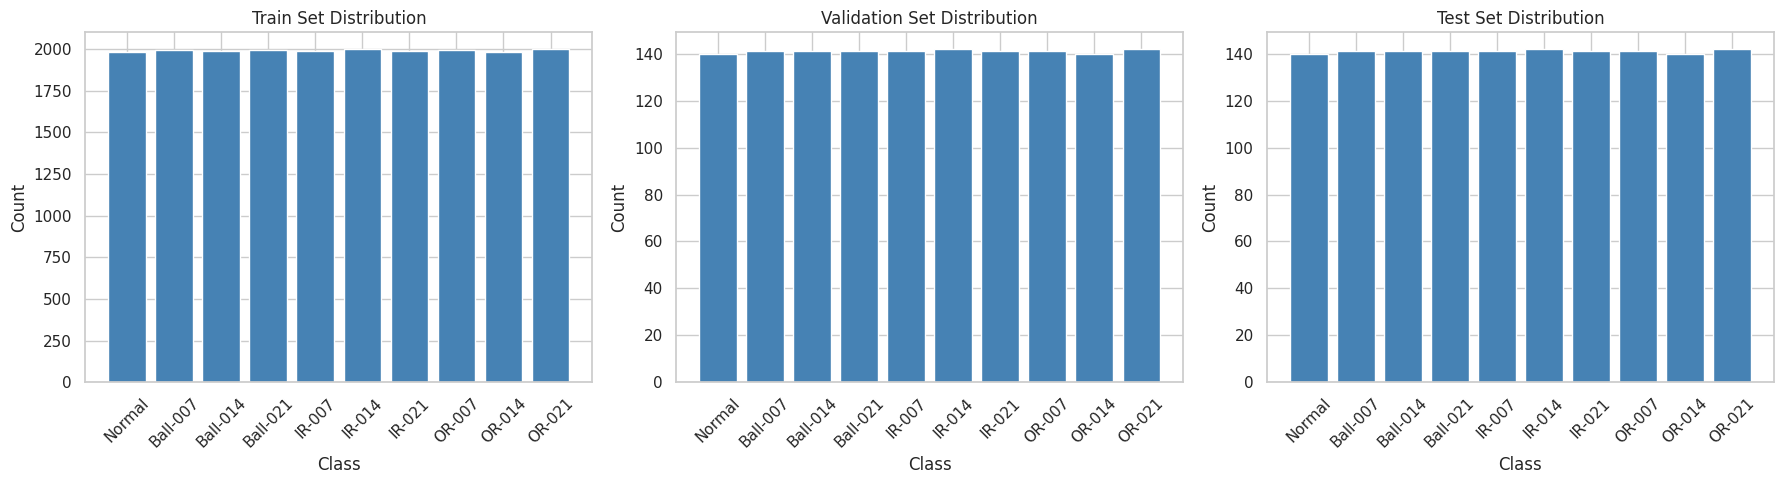

In [15]:
# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (data_y, title) in zip(axes, [
    (y_train, 'Train'),
    (y_val, 'Validation'),
    (y_test, 'Test')
]):
    unique, counts = np.unique(data_y, return_counts=True)
    ax.bar([CLASS_NAMES[i] for i in unique], counts, color='steelblue')
    ax.set_title(f'{title} Set Distribution')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

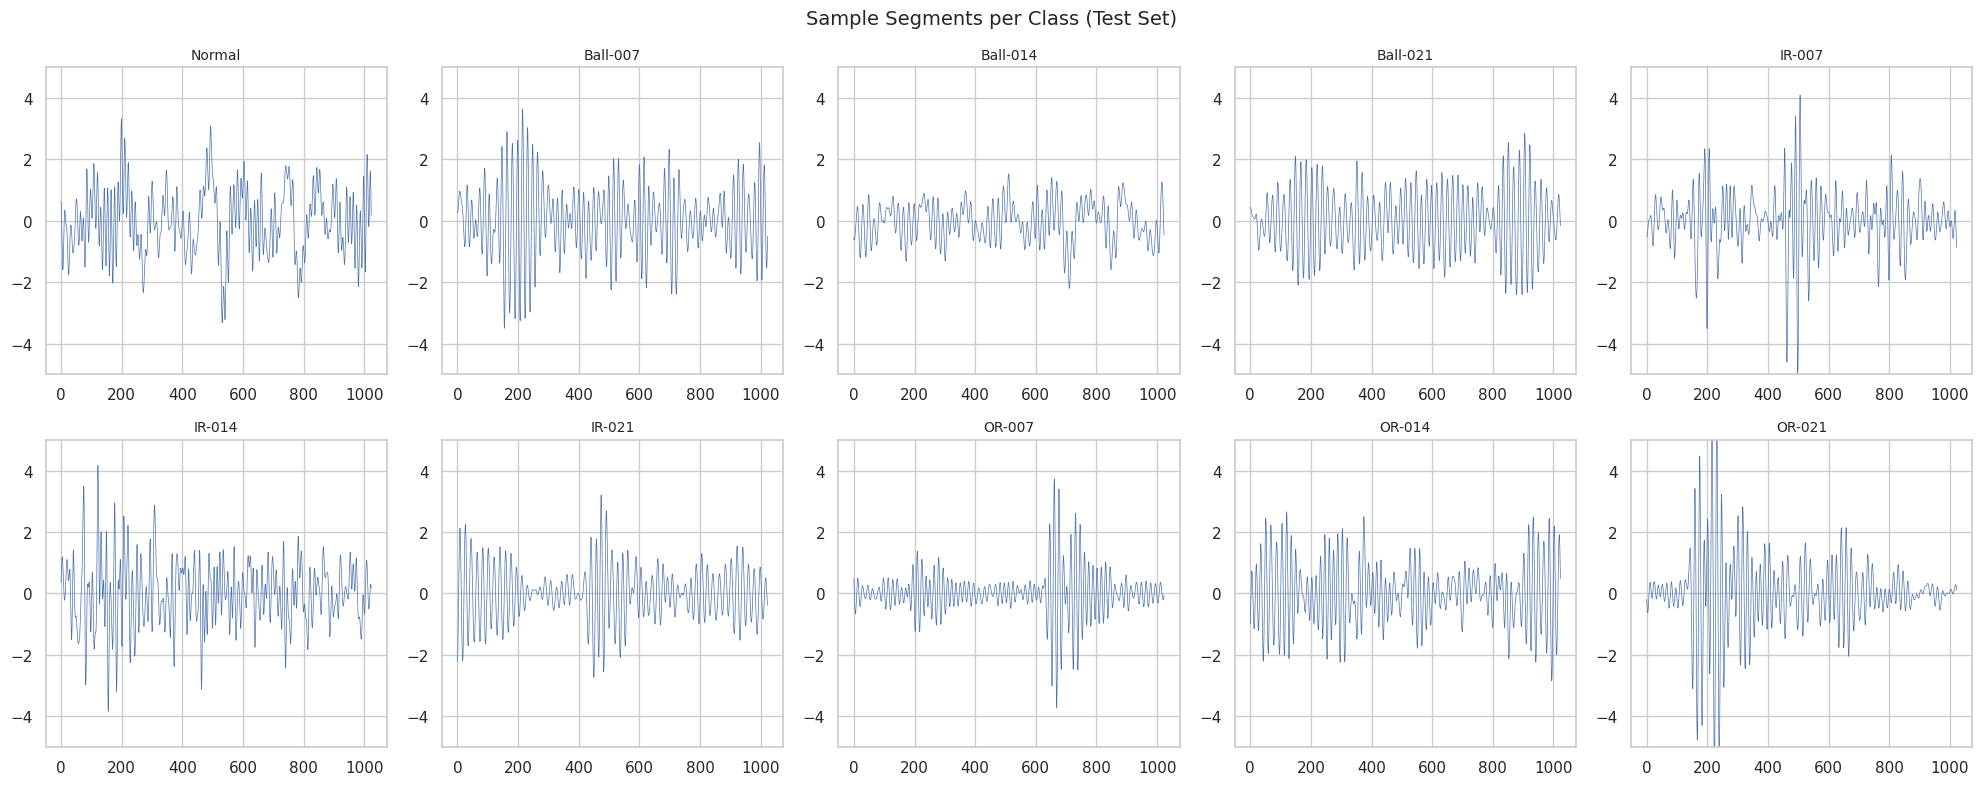

In [16]:
# Visualize sample segments from each class
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for cls_id in range(N_CLASSES):
    # Find first segment of this class in test set
    idx = np.where(y_test == cls_id)[0]
    if len(idx) > 0:
        seg = X_test[idx[0], :, 0]
        axes[cls_id].plot(seg, linewidth=0.5)
        axes[cls_id].set_title(CLASS_NAMES[cls_id], fontsize=10)
        axes[cls_id].set_ylim(-5, 5)
    else:
        axes[cls_id].set_title(f"{CLASS_NAMES[cls_id]} (N/A)")

plt.suptitle('Sample Segments per Class (Test Set)', fontsize=14)
plt.tight_layout()
plt.show()

## 9. CNN Model (Identical Architecture to Paderborn)

In [17]:
def build_cnn_model(input_shape: tuple,
                    n_classes: int = N_CLASSES,
                    learning_rate: float = LEARNING_RATE) -> Model:
    """
    1D CNN for bearing fault classification.
    
    Architecture (NO residual blocks — identical to Paderborn notebook):
      - 4 Conv1D blocks: Conv1D → BatchNorm → ReLU → MaxPool1D
      - GlobalAveragePooling1D
      - Dense(128) → Dropout(0.5)
      - Dense(64)  → Dropout(0.3)
      - Dense(n_classes, softmax)
    """
    inp = Input(shape=input_shape, name='input')
    
    # Block 1
    x = layers.Conv1D(32, kernel_size=7, padding='same', name='conv1')(inp)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool1')(x)
    
    # Block 2
    x = layers.Conv1D(64, kernel_size=5, padding='same', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool2')(x)
    
    # Block 3
    x = layers.Conv1D(128, kernel_size=5, padding='same', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu', name='relu3')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool3')(x)
    
    # Block 4
    x = layers.Conv1D(256, kernel_size=3, padding='same', name='conv4')(x)
    x = layers.BatchNormalization(name='bn4')(x)
    x = layers.Activation('relu', name='relu4')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool4')(x)
    
    # Global pooling + classifier
    x = layers.GlobalAveragePooling1D(name='gap')(x)
    x = layers.Dense(128, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.5, name='drop1')(x)
    x = layers.Dense(64, activation='relu', name='dense2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)
    out = layers.Dense(n_classes, activation='softmax', name='output')(x)
    
    model = Model(inputs=inp, outputs=out, name='CWRU_CNN')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [18]:
# Build the model
input_shape = (WINDOW_SIZE, 1)
model = build_cnn_model(input_shape)
model.summary()

I0000 00:00:1774050775.595044      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774050775.601271      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "CWRU_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1024, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 1024, 32)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1024, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 1024, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 512, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 512, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 512, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 512, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 256, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 256, 128)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling1D)            │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv1D)                  │ (None, 128, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 128, 256)       │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (Activation)              │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling1D)            │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,930 (757.54 KB)

 Trainable params: 192,970 (753.79 KB)

 Non-trainable params: 960 (3.75 KB)

## 10. Training

In [19]:
# Compute class weights to handle imbalance
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(N_CLASSES),
    y=y_train
)
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights:")
for i, w in class_weights.items():
    print(f"  {CLASS_NAMES[i]}: {w:.4f}")

Class weights:
  Normal: 1.0055
  Ball-007: 0.9979
  Ball-014: 1.0009
  Ball-021: 0.9994
  IR-007: 1.0009
  IR-014: 0.9949
  IR-021: 1.0024
  OR-007: 0.9994
  OR-014: 1.0039
  OR-021: 0.9949


In [20]:
# Callbacks (identical to Paderborn notebook)
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_cwru_cnn.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [21]:
# Train the model
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50


I0000 00:00:1774050816.318595     129 service.cc:152] XLA service 0x7d4d08006c70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774050816.318635     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774050816.318639     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774050816.991162     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


  9/312 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.2017 - loss: 2.2302

I0000 00:00:1774050821.652849     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6381 - loss: 0.9771
Epoch 1: val_accuracy improved from -inf to 0.45461, saving model to best_cwru_cnn.keras
312/312 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.6385 - loss: 0.9757 - val_accuracy: 0.4546 - val_loss: 1.9294 - learning_rate: 0.0010
Epoch 2/50
309/312 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8895 - loss: 0.2608
Epoch 2: val_accuracy improved from 0.45461 to 0.94823, saving model to best_cwru_cnn.keras
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8898 - loss: 0.2602 - val_accuracy: 0.9482 - val_loss: 0.1127 - learning_rate: 0.0010
Epoch 3/50
310/312 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9515 - loss: 0.1306
Epoch 3: val_accuracy improved from 0.94823 to 0.96028, saving model to best_cwru_cnn.keras
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9515 - loss: 0.1305 - val_accuracy: 0.9603 - val_loss: 0.1033 - learning_rate: 0.0010
Epoch 4/50
311/312 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/st

## 11. Training History

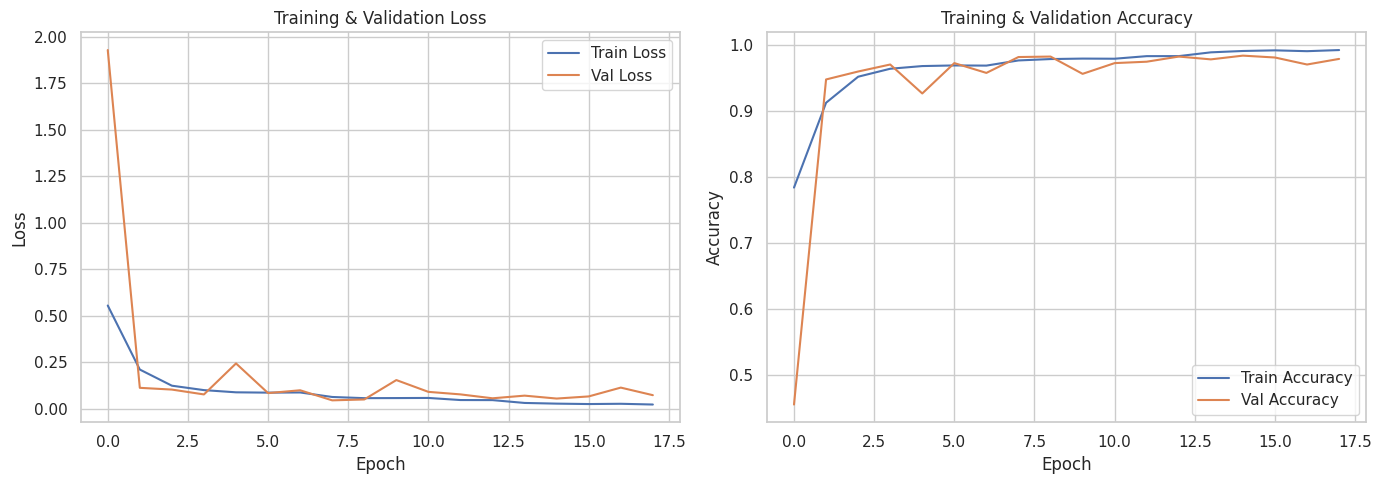

In [22]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training & Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 12. Evaluation

In [23]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# F1 Score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Weighted F1:   {f1:.4f}")

Test Loss:     0.0382
Test Accuracy: 0.9844
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Weighted F1:   0.9844


In [ ]:
# Classification Report
print("\nClassification Report:")
print("=" * 60)
print(classification_report(
    y_test, y_pred,
    target_names=CLASS_NAMES,
    digits=4
))

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix — CWRU CNN (Acc: {test_acc:.4f})')
plt.tight_layout()
plt.show()

In [ ]:
# Normalized Confusion Matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Normalized Confusion Matrix — CWRU CNN')
plt.tight_layout()
plt.show()

## 13. Save Model

In [ ]:
# Save the final model for transfer learning
model.save('cwru_cnn_final.keras')
print("Model saved as 'cwru_cnn_final.keras'")
print("\nThis model can be used as a pre-trained source for transfer learning to Paderborn dataset.")